# AI-Powered Network Intrusion Detection and Cyber Attack Classification System

## Phase 1: Dataset Loading and Inspection

This project uses machine learning to classify network traffic into five classes:

- Normal
- DoS
- Probe
- R2L
- U2R

In this phase, we load the dataset and inspect its structure, columns, data types, missing values, duplicates, unique values, and target distribution.


In [17]:

import pandas as pd

import numpy as np

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Display up to 100 rows when required
pd.set_option("display.max_rows", 100)

## 1. Load the Dataset

In [18]:
# Load the NIDS-28 dataset
df = pd.read_csv("nids28.csv")

# Display the first five rows
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_serror_rate,attack_type,binary_label
0,0.000000,icmp,ftp,S0,58621.112159,224.167888,0,0,0,0.567393,0,0,0.275086,0,0,0.282471,0.000000,0.081022,0.000000,0,0,477,406,0.889354,0.019186,0.049841,0.008362,0.028865,245,235,0.058910,1.000000,1.000000,DoS,1
1,6.108675,tcp,http,SF,1120.981519,506.471977,0,0,0,0.242833,0,1,0.000000,0,0,0.000000,0.207605,0.016063,0.175948,0,0,0,34,0.000000,0.071429,1.000000,0.027415,0.072035,144,223,0.841641,0.015910,0.000000,Normal,0
2,0.000000,tcp,other,REJ,41673.377084,3.994926,0,0,0,0.000000,0,0,0.216673,0,0,0.359390,0.329113,0.009974,0.000000,0,0,402,511,0.725513,0.005937,0.077349,0.178532,0.014780,240,252,0.099369,0.929196,0.970404,DoS,1
3,4.369456,udp,ssh,SF,301.070248,0.000000,0,0,0,0.000000,0,0,0.000000,0,0,0.000000,0.509108,0.124990,0.658686,0,0,123,1,0.099510,0.192984,0.013021,0.830777,0.552373,231,99,0.448487,0.854873,0.013372,Probe,1
4,21.167995,tcp,pop3,REJ,0.000000,2095.714233,0,0,0,7.634635,3,0,0.000000,0,0,0.041904,0.886587,0.000000,0.929166,0,0,12,24,0.000000,0.034204,0.587595,0.460801,0.244273,53,51,0.558974,0.334963,0.104579,R2L,1


## 2. Dataset Shape

In [19]:
# Display the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 28000
Number of columns: 35


In [20]:
# Display column names as an Index objectprint(df.columns)
print(df.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_serror_rate', 'attack_type',
       'binary_label'],
      dtype='str')


In [21]:
# Display the data type of every column
print(df.dtypes)

duration                  float64
protocol_type                 str
service                       str
flag                          str
src_bytes                 float64
dst_bytes                 float64
land                        int64
wrong_fragment              int64
urgent                      int64
hot                       float64
num_failed_logins           int64
logged_in                   int64
num_compromised           float64
root_shell                  int64
su_attempted                int64
num_root                  float64
num_file_creations        float64
num_shells                float64
num_access_files          float64
is_host_login               int64
is_guest_login              int64
count                       int64
srv_count                   int64
serror_rate               float64
rerror_rate               float64
same_srv_rate             float64
diff_srv_rate             float64
srv_diff_host_rate        float64
dst_host_count              int64
dst_host_srv_c

In [22]:
# Display general information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   duration                28000 non-null  float64
 1   protocol_type           28000 non-null  str    
 2   service                 28000 non-null  str    
 3   flag                    28000 non-null  str    
 4   src_bytes               28000 non-null  float64
 5   dst_bytes               28000 non-null  float64
 6   land                    28000 non-null  int64  
 7   wrong_fragment          28000 non-null  int64  
 8   urgent                  28000 non-null  int64  
 9   hot                     28000 non-null  float64
 10  num_failed_logins       28000 non-null  int64  
 11  logged_in               28000 non-null  int64  
 12  num_compromised         28000 non-null  float64
 13  root_shell              28000 non-null  int64  
 14  su_attempted            28000 non-null  int64  
 

In [23]:
# Count missing values in every column
missing_values = df.isnull().sum()

# Display the result
print(missing_values)

duration                  0
protocol_type             0
service                   0
flag                      0
src_bytes                 0
dst_bytes                 0
land                      0
wrong_fragment            0
urgent                    0
hot                       0
num_failed_logins         0
logged_in                 0
num_compromised           0
root_shell                0
su_attempted              0
num_root                  0
num_file_creations        0
num_shells                0
num_access_files          0
is_host_login             0
is_guest_login            0
count                     0
srv_count                 0
serror_rate               0
rerror_rate               0
same_srv_rate             0
diff_srv_rate             0
srv_diff_host_rate        0
dst_host_count            0
dst_host_srv_count        0
dst_host_same_srv_rate    0
dst_host_diff_srv_rate    0
dst_host_serror_rate      0
attack_type               0
binary_label              0
dtype: int64


In [24]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [25]:
# Count unique values in every column
unique_counts = df.nunique(dropna=False)

# Display the result
print(unique_counts)

duration                  20375
protocol_type                 3
service                       9
flag                          7
src_bytes                 25900
dst_bytes                 24761
land                          1
wrong_fragment                2
urgent                        1
hot                       21658
num_failed_logins             4
logged_in                     2
num_compromised           20803
root_shell                    2
su_attempted                  2
num_root                  19283
num_file_creations        17766
num_shells                17359
num_access_files          17868
is_host_login                 1
is_guest_login                2
count                       498
srv_count                   352
serror_rate               22520
rerror_rate               21781
same_srv_rate             24269
diff_srv_rate             24200
srv_diff_host_rate        23073
dst_host_count              256
dst_host_srv_count          256
dst_host_same_srv_rate    24978
dst_host

In [26]:
# Identify columns with object/string data type
[print("-", col) for col in df.select_dtypes(include=["object"]).columns]

- protocol_type
- service
- flag
- attack_type


C:\Users\abhin\AppData\Local\Temp\ipykernel_13216\1790327385.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  [print("-", col) for col in df.select_dtypes(include=["object"]).columns]


[None, None, None, None]

## 11. Identify the Target Variable

The target variable is the value that our machine learning model will learn to predict.

For this project, we need a five-class classification problem:

- Normal
- DoS
- Probe
- R2L
- U2R

We inspect the available target-related columns before defining the final target.

In [27]:
# Display the unique values in attack_type
print("Unique attack types:")
print(df["attack_type"].unique())

print("\nNumber of classes:")
print(df["attack_type"].nunique())

Unique attack types:
<StringArray>
['DoS', 'Normal', 'Probe', 'R2L', 'U2R']
Length: 5, dtype: str

Number of classes:
5


## 12. Target Class Distribution

We examine how many records belong to each attack class.

This is important because an imbalanced class distribution can affect classification performance.

In [28]:
# Count the number of records in each attack class
target_counts = df["attack_type"].value_counts()

print(target_counts)

attack_type
Normal    12000
DoS        8000
Probe      4000
R2L        3000
U2R        1000
Name: count, dtype: int64


In [29]:
# Find columns that contain only one unique value
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == 1
]

print("Constant columns:")

for column in constant_columns:
    print("-", column)

Constant columns:
- land
- urgent
- is_host_login


## 14. Inspect the Binary Label

In [30]:
# Create a cross-tabulation between attack_type and binary_label
binary_label_table = pd.crosstab(
    df["attack_type"],
    df["binary_label"]
)

print(binary_label_table)

binary_label      0     1
attack_type              
DoS               0  8000
Normal        12000     0
Probe             0  4000
R2L               0  3000
U2R               0  1000


In [31]:
# Define the target column
TARGET = "attack_type"

# Columns that should not be used as model input features
excluded_columns = [
    TARGET,
    "binary_label"
]

print("Target column:", TARGET)
print("Excluded columns:", excluded_columns)
print("Constant columns:", constant_columns)

Target column: attack_type
Excluded columns: ['attack_type', 'binary_label']
Constant columns: ['land', 'urgent', 'is_host_login']


In [32]:
# Combine all columns that should not be used as model inputs
columns_to_exclude = excluded_columns + constant_columns

# Remove duplicates from the exclusion list
columns_to_exclude = list(dict.fromkeys(columns_to_exclude))

# Create the initial feature list
feature_columns = [
    column
    for column in df.columns
    if column not in columns_to_exclude
]

print("Number of initial input features:", len(feature_columns))

print("\nInput features:")

for column in feature_columns:
    print("-", column)

Number of initial input features: 30

Input features:
- duration
- protocol_type
- service
- flag
- src_bytes
- dst_bytes
- wrong_fragment
- hot
- num_failed_logins
- logged_in
- num_compromised
- root_shell
- su_attempted
- num_root
- num_file_creations
- num_shells
- num_access_files
- is_guest_login
- count
- srv_count
- serror_rate
- rerror_rate
- same_srv_rate
- diff_srv_rate
- srv_diff_host_rate
- dst_host_count
- dst_host_srv_count
- dst_host_same_srv_rate
- dst_host_diff_srv_rate
- dst_host_serror_rate


## Phase 1 Conclusion

The dataset contains 28,000 records and 35 columns.

The target variable is `attack_type`, which contains five classes:

- Normal
- DoS
- Probe
- R2L
- U2R

The dataset contains no missing values and no duplicate records.

The categorical input features are:

- protocol_type
- service
- flag

The columns `land`, `urgent`, and `is_host_login` are constant and therefore do not provide useful predictive information.

The `binary_label` column is excluded because it is derived directly from the target variable and would cause target leakage.

After excluding the target, binary label, and constant columns, 30 input features remain for further preprocessing and feature selection.

The original dataset will not be modified at this stage.

# Phase 2: Data Cleaning and Preprocessing

In this phase, we clean and prepare the dataset for machine learning.

The cleaning process is based on the actual characteristics of the NIDS-28 dataset. We will check missing values, duplicate records, numerical distributions, skewness, outliers, and categorical features.

Because unusual network traffic may represent genuine cyber attacks, outliers will not be removed automatically.

## 1. Separate Features and Target

The target variable is `attack_type`.

We create:

- `X` → input features
- `y` → target variable

The columns identified as target-related or constant during Phase 1 are excluded from the initial feature matrix.

In [33]:
# Create the input feature matrix
X = df[feature_columns].copy()

# Create the target variable
y = df[TARGET].copy()

# Display the shapes
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (28000, 30)
Target shape: (28000,)


In [34]:
# Identify numerical input features
numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

# Identify categorical input features
categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
for column in categorical_features:
    print("-", column)

print("\nNumerical features:")
for column in numerical_features:
    print("-", column)

Number of numerical features: 27
Number of categorical features: 3

Categorical features:
- protocol_type
- service
- flag

Numerical features:
- duration
- src_bytes
- dst_bytes
- wrong_fragment
- hot
- num_failed_logins
- logged_in
- num_compromised
- root_shell
- su_attempted
- num_root
- num_file_creations
- num_shells
- num_access_files
- is_guest_login
- count
- srv_count
- serror_rate
- rerror_rate
- same_srv_rate
- diff_srv_rate
- srv_diff_host_rate
- dst_host_count
- dst_host_srv_count
- dst_host_same_srv_rate
- dst_host_diff_srv_rate
- dst_host_serror_rate


In [35]:
# Check missing values in the input features
missing_by_column = X.isnull().sum()

print("Total missing values:", missing_by_column.sum())

# Display only columns containing missing values
missing_by_column[missing_by_column > 0]

Total missing values: 0


Series([], dtype: int64)

In [36]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)


Duplicate rows: 0


## 5. Numerical Feature Statistics

We inspect descriptive statistics such as:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

This helps us understand the range and distribution of the numerical network features before deciding how to handle skewness and outliers.

In [37]:
# Display descriptive statistics for numerical features
X[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,28000.0,3.722666,5.422500,0.0,0.000000,1.499016,5.234281,43.461097
src_bytes,28000.0,13361.604363,21496.711131,0.0,377.964405,892.381910,27786.824006,114168.857284
dst_bytes,28000.0,663.298973,800.492322,0.0,114.056096,382.590159,959.610019,8759.419839
wrong_fragment,28000.0,0.097143,0.296157,0.0,0.000000,0.000000,0.000000,1.000000
hot,28000.0,1.932293,2.177616,0.0,0.123330,1.303619,2.945364,19.178097
num_failed_logins,28000.0,0.368000,0.735640,0.0,0.000000,0.000000,1.000000,3.000000
logged_in,28000.0,0.631857,0.482309,0.0,0.000000,1.000000,1.000000,1.000000
num_compromised,28000.0,0.600493,1.072355,0.0,0.000000,0.257253,0.687437,13.572556
root_shell,28000.0,0.020357,0.141221,0.0,0.000000,0.000000,0.000000,1.000000
su_attempted,28000.0,0.020214,0.140735,0.0,0.000000,0.000000,0.000000,1.000000


In [38]:
# Calculate skewness for every numerical feature
skewness = X[numerical_features].skew().sort_values(
    ascending=False
)

# Display skewness values
skewness

is_guest_login            8.144242
su_attempted              6.818767
root_shell                6.793271
num_shells                6.011768
num_access_files          5.223278
num_file_creations        5.169212
num_root                  4.885910
num_compromised           4.081404
wrong_fragment            2.720755
duration                  2.427075
dst_bytes                 2.417207
rerror_rate               2.406323
srv_diff_host_rate        2.314930
num_failed_logins         2.202697
diff_srv_rate             1.830178
hot                       1.789597
src_bytes                 1.364399
dst_host_serror_rate      0.945019
serror_rate               0.944259
srv_count                 0.919505
count                     0.742013
dst_host_diff_srv_rate    0.276608
same_srv_rate            -0.235895
dst_host_same_srv_rate   -0.258000
dst_host_srv_count       -0.413743
logged_in                -0.546814
dst_host_count           -1.061306
dtype: float64

In [39]:
# Identify highly skewed numerical features
highly_skewed_features = skewness[
    skewness.abs() > 1
]

print("Highly skewed features:")
print(highly_skewed_features)

Highly skewed features:
is_guest_login        8.144242
su_attempted          6.818767
root_shell            6.793271
num_shells            6.011768
num_access_files      5.223278
num_file_creations    5.169212
num_root              4.885910
num_compromised       4.081404
wrong_fragment        2.720755
duration              2.427075
dst_bytes             2.417207
rerror_rate           2.406323
srv_diff_host_rate    2.314930
num_failed_logins     2.202697
diff_srv_rate         1.830178
hot                   1.789597
src_bytes             1.364399
dst_host_count       -1.061306
dtype: float64


In [40]:
# Calculate the number of potential IQR outliers
# for each numerical feature

outlier_summary = []

for column in numerical_features:
    Q1 = X[column].quantile(0.25)
    Q3 = X[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (X[column] < lower_bound) |
        (X[column] > upper_bound)
    ).sum()
    
    outlier_percentage = (outliers / len(X)) * 100
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outliers,
        "Outlier Percentage": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df.sort_values(
    by="Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
20,diff_srv_rate,0.039568,0.166644,0.127076,-0.151047,0.357258,5037,17.989286
18,rerror_rate,0.012309,0.081890,0.069581,-0.092062,0.186261,3995,14.267857
21,srv_diff_host_rate,0.011593,0.125602,0.114008,-0.159419,0.296614,3662,13.078571
3,wrong_fragment,0.000000,0.000000,0.000000,0.000000,0.000000,2720,9.714286
7,num_compromised,0.000000,0.687437,0.687437,-1.031156,1.718594,2258,8.064286
12,num_shells,0.000000,0.140196,0.140196,-0.210295,0.350491,2057,7.346429
11,num_file_creations,0.000000,0.352756,0.352756,-0.529134,0.881890,2003,7.153571
0,duration,0.000000,5.234281,5.234281,-7.851422,13.085703,1843,6.582143
13,num_access_files,0.000000,0.346325,0.346325,-0.519487,0.865812,1802,6.435714
10,num_root,0.000000,0.582569,0.582569,-0.873854,1.456423,1499,5.353571


In [41]:
# Display unique value counts for numerical features
numeric_unique_counts = (
    X[numerical_features]
    .nunique()
    .sort_values()
)

print(numeric_unique_counts)

wrong_fragment                2
logged_in                     2
su_attempted                  2
root_shell                    2
is_guest_login                2
num_failed_logins             4
dst_host_srv_count          256
dst_host_count              256
srv_count                   352
count                       498
num_shells                17359
num_file_creations        17766
num_access_files          17868
num_root                  19283
duration                  20375
num_compromised           20803
hot                       21658
rerror_rate               21781
serror_rate               22520
dst_host_serror_rate      22530
srv_diff_host_rate        23073
diff_srv_rate             24200
same_srv_rate             24269
dst_bytes                 24761
dst_host_diff_srv_rate    24826
dst_host_same_srv_rate    24978
src_bytes                 25900
dtype: int64


In [42]:
# Display the number of categories in each categorical feature
for column in categorical_features:
    print(f"\n{column}")
    print("Number of categories:", X[column].nunique())
    print("Categories:", X[column].unique())


protocol_type
Number of categories: 3
Categories: <StringArray>
['icmp', 'tcp', 'udp']
Length: 3, dtype: str

service
Number of categories: 9
Categories: <StringArray>
['ftp', 'http', 'other', 'ssh', 'pop3', 'imap', 'smtp', 'dns', 'telnet']
Length: 9, dtype: str

flag
Number of categories: 7
Categories: <StringArray>
['S0', 'SF', 'REJ', 'RSTO', 'RSTOS0', 'OTH', 'SH']
Length: 7, dtype: str


In [43]:
# Display the target classes and their counts
print("Target classes:")
print(sorted(y.unique()))

print("\nTarget distribution:")
print(y.value_counts())

Target classes:
['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

Target distribution:
attack_type
Normal    12000
DoS        8000
Probe      4000
R2L        3000
U2R        1000
Name: count, dtype: int64


## 14. Final Cleaning Decision

Based on the inspection performed so far:

- There are no missing values.
- There are no duplicate records.
- Constant columns were identified during Phase 1 and excluded.
- `binary_label` is excluded because it is derived from the target.
- Categorical features will be one-hot encoded.
- Numerical features will be retained.
- Potential outliers will be retained because they may represent genuine intrusion behavior.
- Highly skewed features will be inspected but will not be blindly transformed.
- Feature scaling will be performed later inside the machine learning pipeline.

The original dataset remains unchanged.

# Phase 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis is used to understand the structure and patterns in the dataset before training machine learning models.

In this phase, we visualize:

- Target class distribution
- Numerical feature distributions
- Potential outliers
- Relationships between selected features
- Correlations between numerical variables
- Differences between attack classes

All visualizations are based on the actual NIDS-28 dataset.

In [44]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean default plotting style
sns.set_theme(style="whitegrid")

# Set a reasonable default figure size
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Count Plot - Attack Class Distribution

The count plot shows the number of records belonging to each attack class.

This helps us understand the distribution of the target variable and identify whether some classes have substantially fewer observations than others.

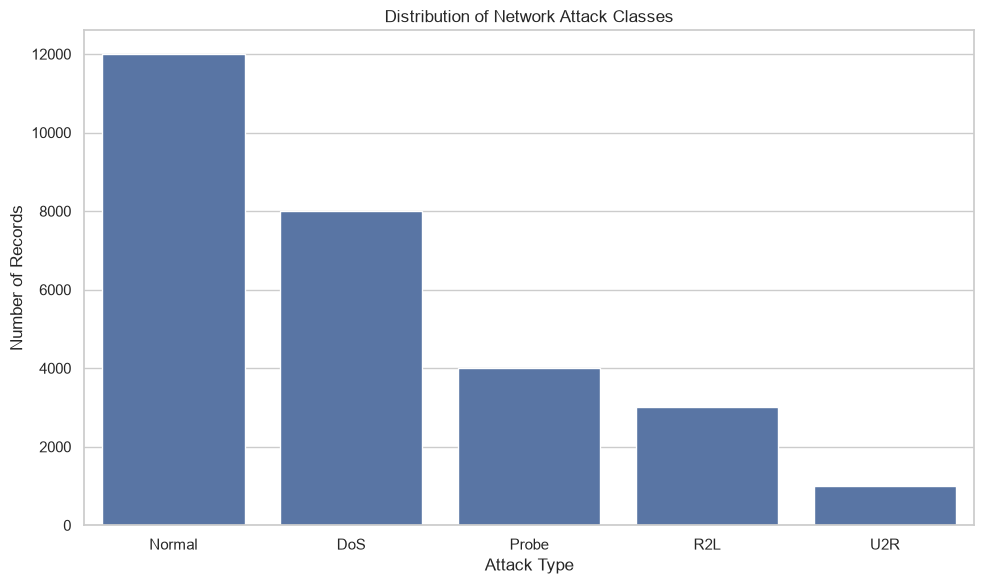

In [45]:
# Create a count plot for the target classes
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="attack_type",
    order=df["attack_type"].value_counts().index
)

plt.title("Distribution of Network Attack Classes")
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

## 2. Pie Chart - Percentage of Attack Classes

The pie chart shows the proportion of each attack class in the complete dataset.

This provides another way of understanding the class distribution using percentages.

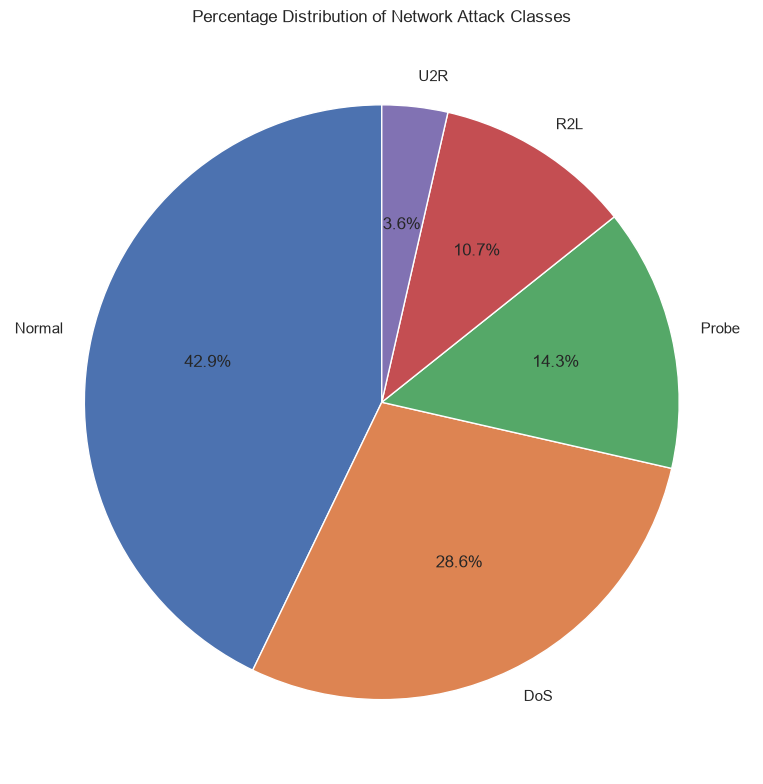

In [46]:
# Calculate the number of records in each attack class
attack_counts = df["attack_type"].value_counts()

# Create the pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    attack_counts.values,
    labels=attack_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Network Attack Classes")

plt.tight_layout()
plt.show()

## 3. Histograms - Numerical Feature Distributions

Histograms show how numerical values are distributed.

We use selected network-related features rather than plotting every feature simultaneously so that the distributions remain readable.

The selected features represent:

- Connection duration
- Source bytes
- Destination bytes
- Connection count

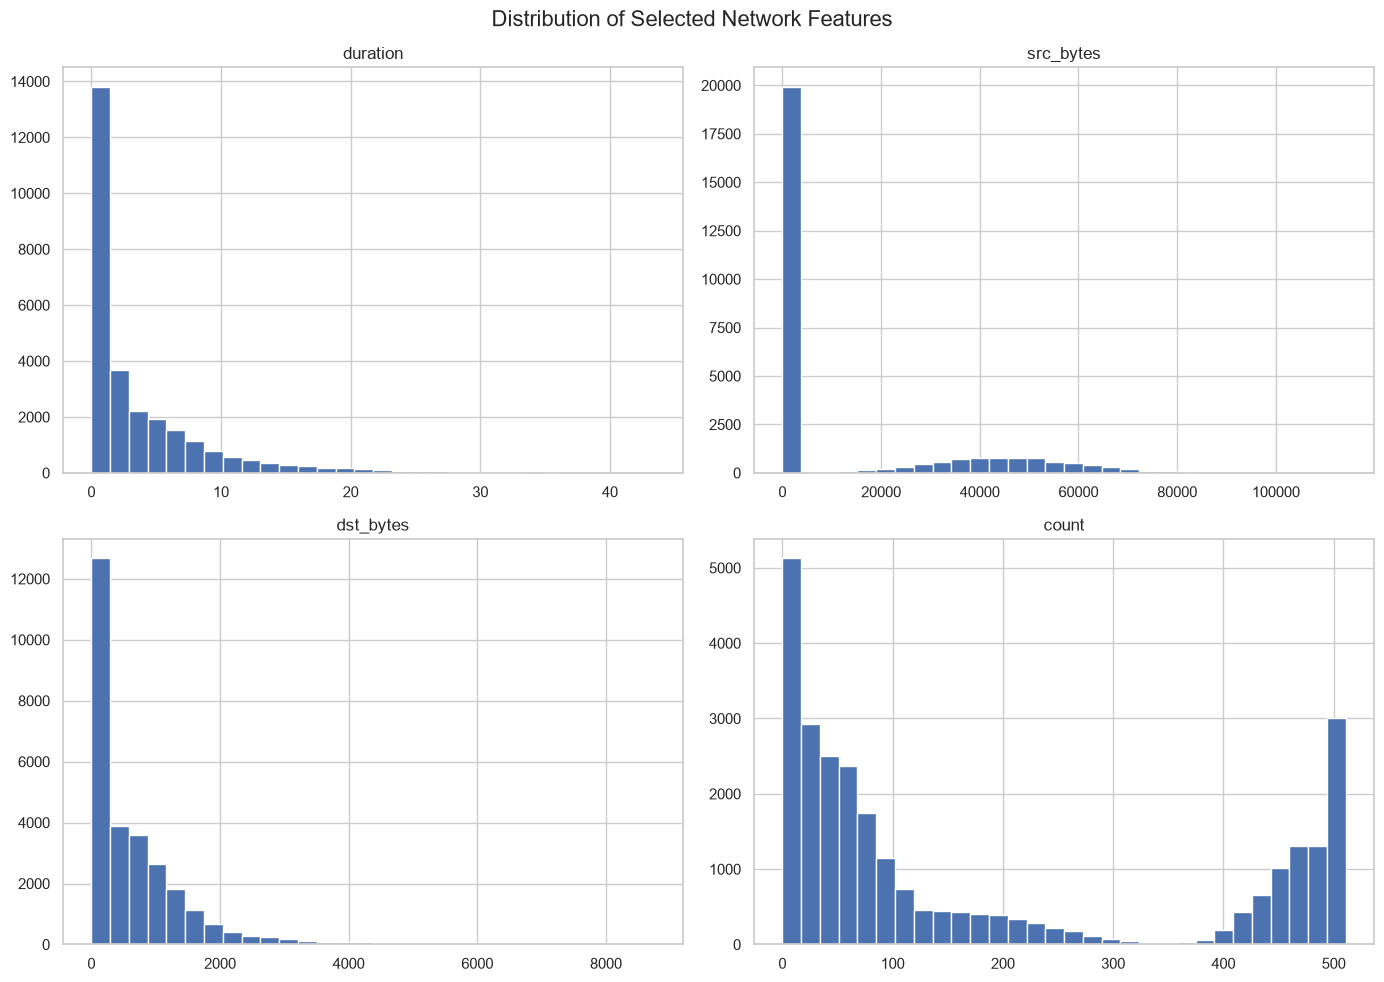

In [47]:
# Select representative numerical network features
hist_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "count"
]

# Create histograms
X[hist_features].hist(
    bins=30,
    figsize=(14, 10)
)

plt.suptitle(
    "Distribution of Selected Network Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 4. Boxplots - Detecting Potential Extreme Values

Boxplots show the median, quartiles, spread and potential extreme values of numerical features.

We use the same representative features from the histogram so that the results are easy to compare.

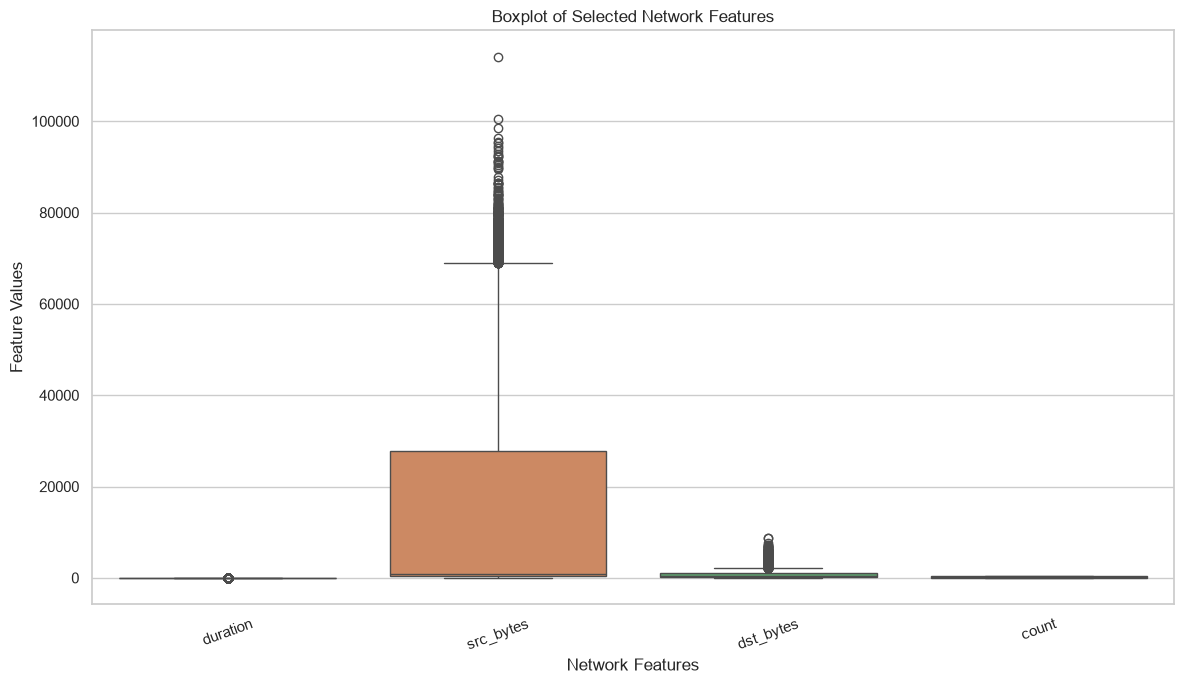

In [48]:
# Create a boxplot for selected numerical features
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=X[hist_features]
)

plt.title("Boxplot of Selected Network Features")
plt.xlabel("Network Features")
plt.ylabel("Feature Values")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 5. Correlation Heatmap

A correlation heatmap shows the strength and direction of relationships between numerical features.

Correlation values range from -1 to +1:

- +1 indicates a strong positive relationship
- -1 indicates a strong negative relationship
- 0 indicates little or no linear relationship

The heatmap can also help identify highly correlated features that may contain similar information.

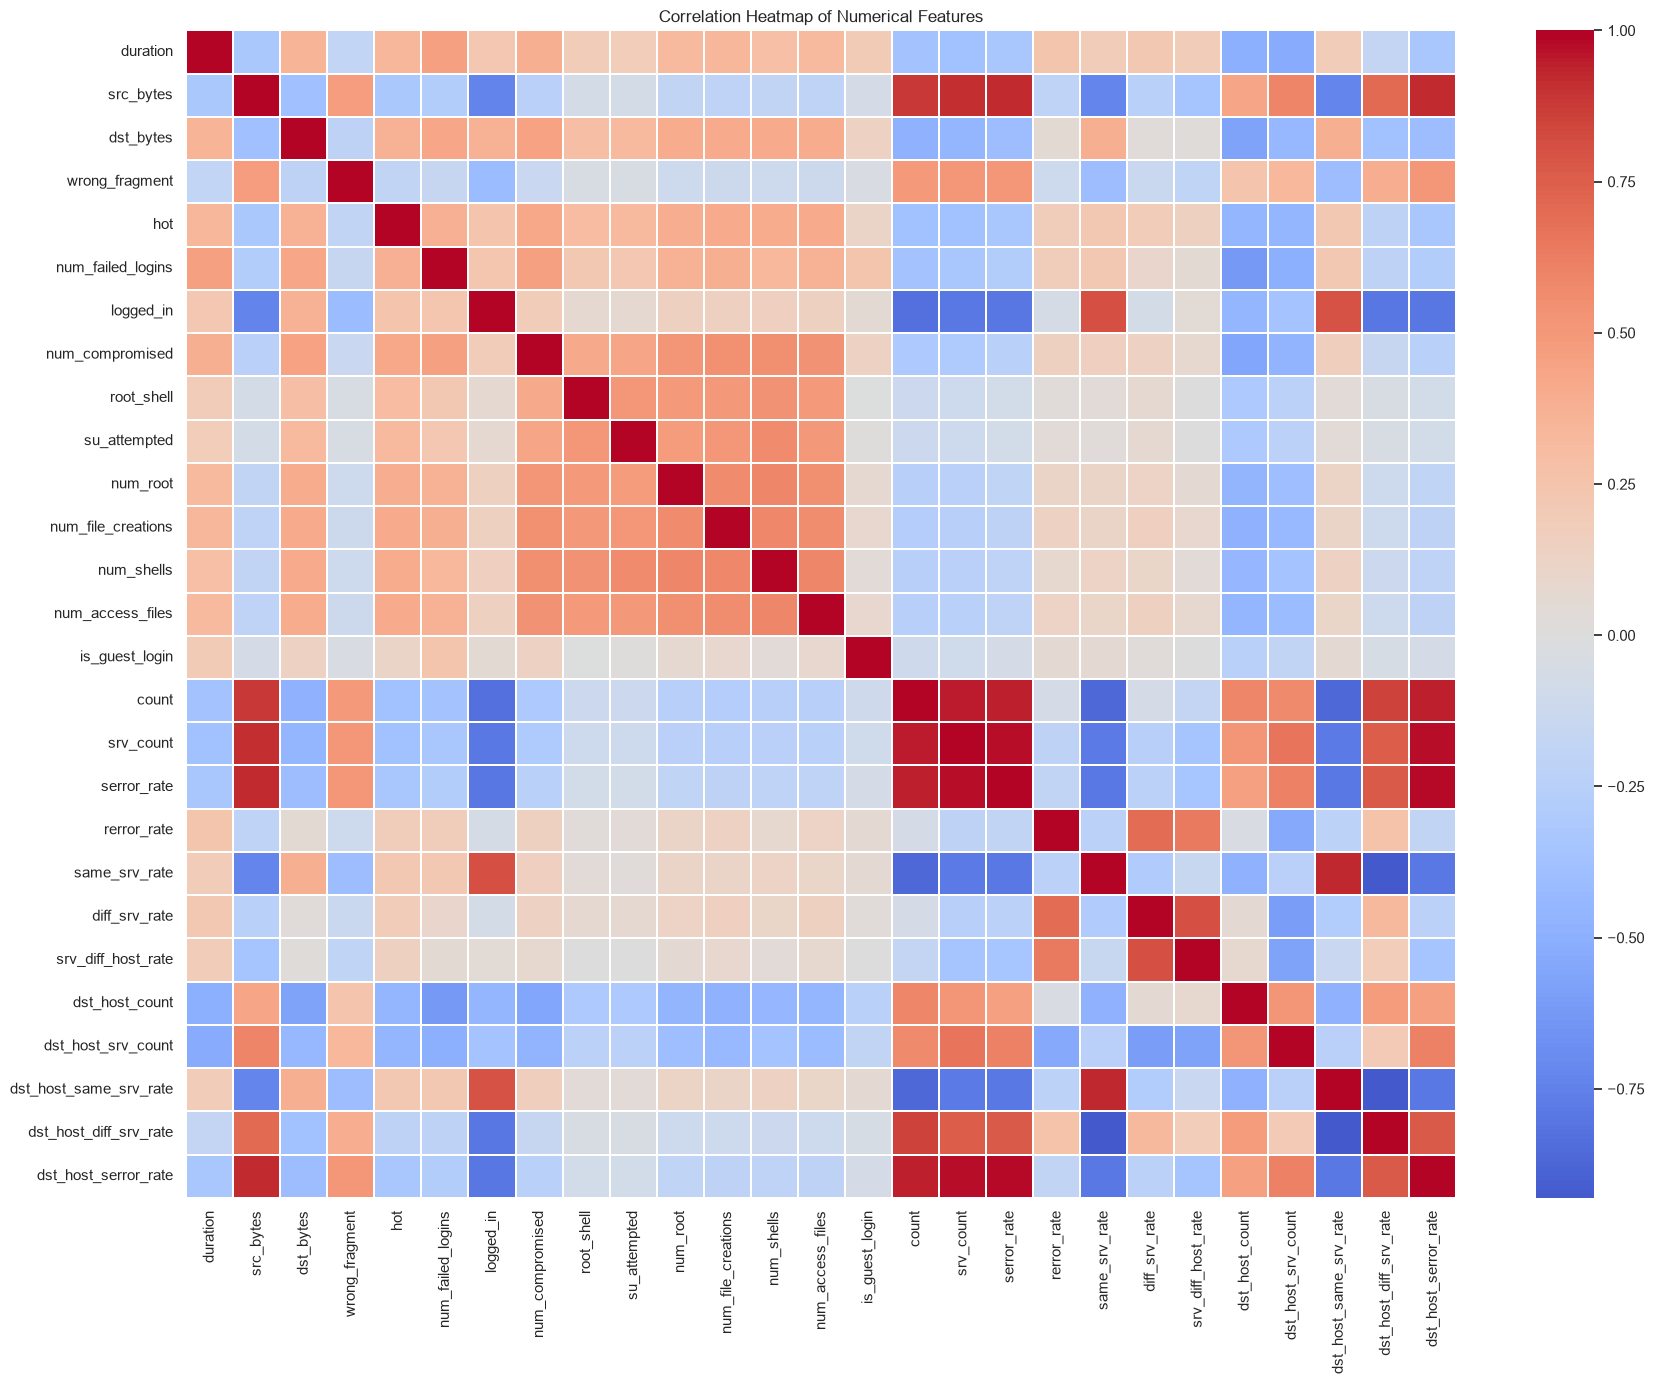

In [49]:
# Calculate the correlation matrix
correlation_matrix = X[numerical_features].corr()

# Create the heatmap
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()
plt.show()

## 6. KDE Plot - Connection Duration Distribution

A KDE plot provides a smooth estimate of the distribution of a numerical variable.

We compare connection duration across attack classes to observe how the distributions differ.

This visualization helps identify whether some attack classes show different patterns in connection duration.

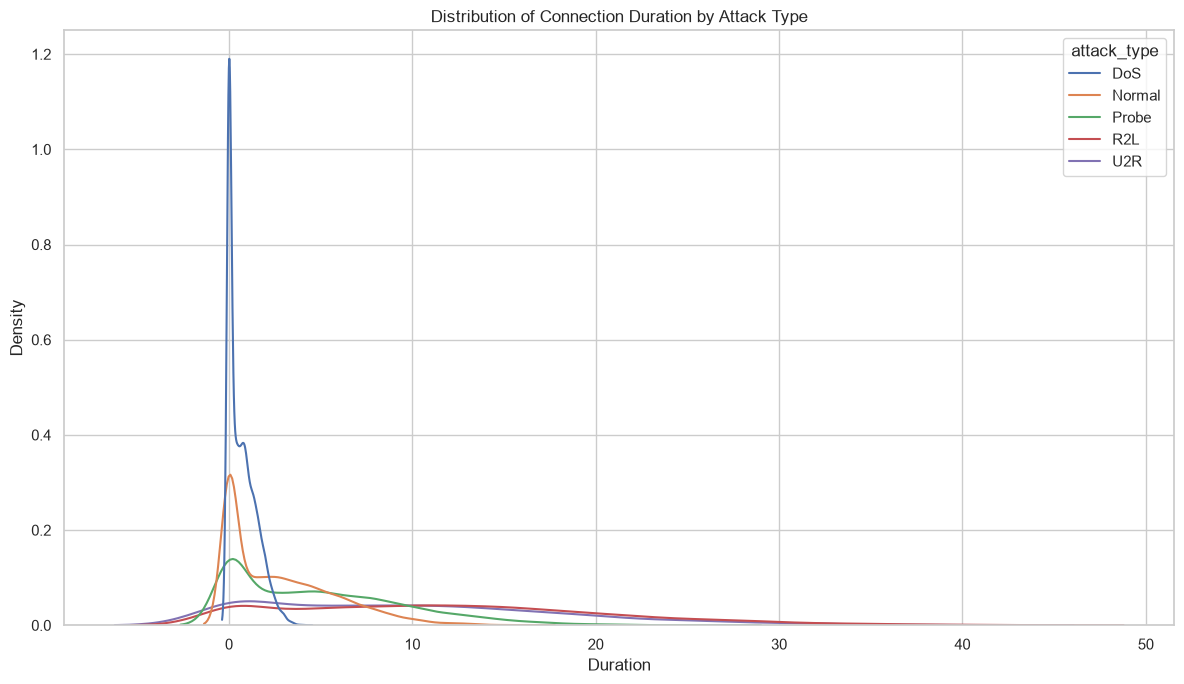

In [50]:
# Create KDE plot for connection duration
plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df,
    x="duration",
    hue="attack_type",
    fill=False,
    common_norm=False
)

plt.title("Distribution of Connection Duration by Attack Type")
plt.xlabel("Duration")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## 10. EDA Summary

The exploratory analysis provides the following observations:

1. The dataset contains five network traffic classes.
2. Normal traffic is the largest class.
3. U2R is the smallest class and represents a minority class.
4. Several numerical features are highly skewed.
5. Some numerical features contain extreme values.
6. Extreme values were not automatically removed because they may represent genuine intrusion behavior.
7. Numerical features show different degrees of correlation.
8. Selected network features show different distributions across attack classes.
9. The dataset does not contain a meaningful timestamp, so a true time-series analysis is not appropriate.
10. These observations will guide feature engineering, feature selection and model development.

# Phase 4 - Feature Engineering and Feature Selection

In this phase, the dataset features are prepared for machine learning.

Feature engineering is used to create or improve useful input features when necessary.

Feature selection is performed to identify the most relevant features using:
1. Random Forest Feature Importance
2. SelectKBest

Feature selection is performed using the training data only to avoid data leakage.

In [51]:
# Display the current input features

print("Number of input features:", X.shape[1])
print("\nInput features:")
print(X.columns.tolist())

Number of input features: 30

Input features:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_serror_rate']


In [52]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (22400, 30)
Testing feature shape: (5600, 30)
Training target shape: (22400,)
Testing target shape: (5600,)


In [53]:
# Create copies so the original X_train and X_test remain unchanged

X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# Feature engineering: total data transferred
X_train_fe["total_bytes"] = (
    X_train_fe["src_bytes"] + X_train_fe["dst_bytes"]
)

X_test_fe["total_bytes"] = (
    X_test_fe["src_bytes"] + X_test_fe["dst_bytes"]
)

# Feature engineering: total error rate
X_train_fe["total_error_rate"] = (
    X_train_fe["serror_rate"] + X_train_fe["rerror_rate"]
)

X_test_fe["total_error_rate"] = (
    X_test_fe["serror_rate"] + X_test_fe["rerror_rate"]
)

print("Original number of features:", X_train.shape[1])
print("Number of features after feature engineering:", X_train_fe.shape[1])

Original number of features: 30
Number of features after feature engineering: 32


In [54]:
# Display the newly created features

print("Newly created features:")

print(
    X_train_fe[
        ["total_bytes", "total_error_rate"]
    ].head()
)

Newly created features:
       total_bytes  total_error_rate
25620  1090.347678          0.160256
22102   782.622725          0.064195
19546  1502.719063          0.139636
16446     0.000000          0.037932
15002   227.094879          0.451742


In [55]:
# Identify categorical and numerical features

categorical_features = X_train_fe.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features_fe = X_train_fe.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features_fe))

Categorical features:
['protocol_type', 'service', 'flag']

Number of numerical features: 29


C:\Users\abhin\AppData\Local\Temp\ipykernel_13216\3162341943.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_fe.select_dtypes(


In [56]:
from sklearn.preprocessing import OneHotEncoder

# Create the encoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fit encoder only on training data

X_train_encoded = encoder.fit_transform(
    X_train_fe[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test_fe[categorical_features]
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (22400, 19)
Encoded testing shape: (5600, 19)


In [57]:
import pandas as pd

# Convert encoded categorical features into a DataFrame

encoded_feature_names = encoder.get_feature_names_out(
    categorical_features
)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train_fe.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test_fe.index
)

# Select numerical features

X_train_numeric = X_train_fe[numerical_features_fe]
X_test_numeric = X_test_fe[numerical_features_fe]

# Combine numerical and encoded categorical features

X_train_processed = pd.concat(
    [X_train_numeric, X_train_encoded_df],
    axis=1
)

X_test_processed = pd.concat(
    [X_test_numeric, X_test_encoded_df],
    axis=1
)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (22400, 48)
Processed testing shape: (5600, 48)


In [58]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest model for feature importance

rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using training data only

rf_selector.fit(
    X_train_processed,
    y_train
)

# Get feature importance values

feature_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train_processed.columns
).sort_values(ascending=False)

# Display the top 20 features

print("Top 20 Features According to Random Forest:")
print(feature_importance.head(20))

Top 20 Features According to Random Forest:
dst_host_diff_srv_rate    0.139439
serror_rate               0.081445
count                     0.072100
dst_host_serror_rate      0.070664
dst_host_count            0.061361
diff_srv_rate             0.057570
dst_host_same_srv_rate    0.057337
srv_count                 0.057004
dst_host_srv_count        0.051573
same_srv_rate             0.050761
total_bytes               0.044836
total_error_rate          0.043834
src_bytes                 0.031086
srv_diff_host_rate        0.024951
rerror_rate               0.023943
num_failed_logins         0.021960
num_access_files          0.016340
num_compromised           0.014342
num_shells                0.014047
num_file_creations        0.013828
dtype: float64


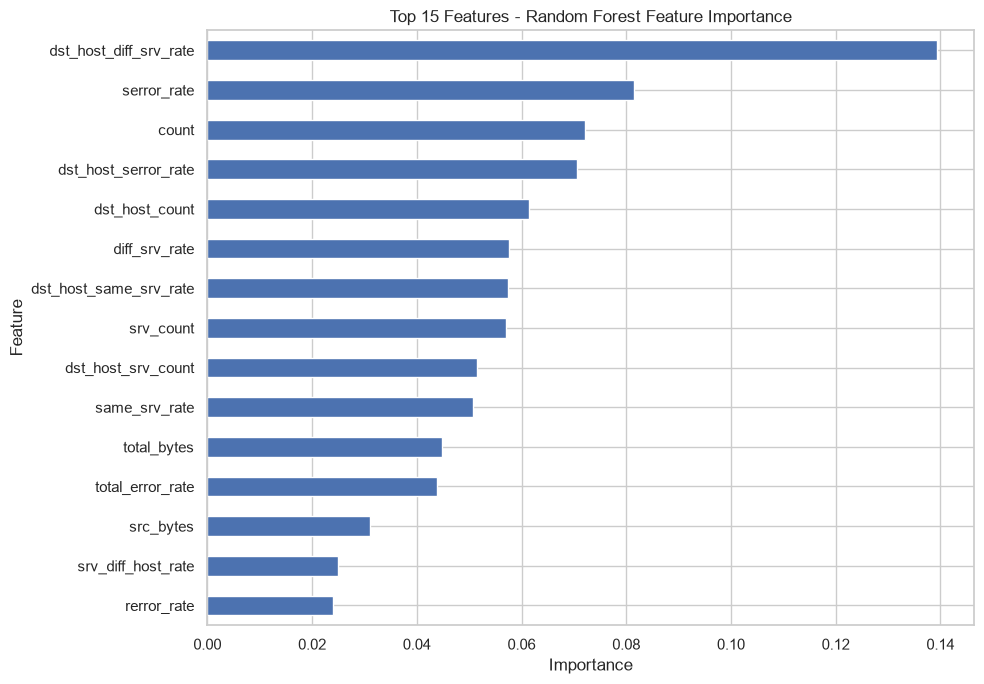

In [59]:
# Plot the top 15 important features

top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_features.plot(kind="barh")

plt.title("Top 15 Features - Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [60]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Select the top 20 features using Mutual Information

k = min(20, X_train_processed.shape[1])

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_processed,
    y_train
)

X_test_selected = selector.transform(
    X_test_processed
)

print("Original processed feature count:", X_train_processed.shape[1])
print("Selected feature count:", X_train_selected.shape[1])

Original processed feature count: 48
Selected feature count: 20


In [61]:
# Get the names of the selected features

selected_feature_names = X_train_processed.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_feature_names.tolist())

Selected Features:
['duration', 'src_bytes', 'dst_bytes', 'logged_in', 'num_compromised', 'num_shells', 'count', 'srv_count', 'serror_rate', 'rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_serror_rate', 'total_bytes', 'total_error_rate']


In [62]:
# Display the SelectKBest feature scores

kbest_scores = pd.Series(
    selector.scores_,
    index=X_train_processed.columns
).sort_values(ascending=False)

print("Top SelectKBest Features:")
print(kbest_scores.head(20))

Top SelectKBest Features:
count                     0.945338
total_error_rate          0.889620
dst_host_diff_srv_rate    0.885006
same_srv_rate             0.883958
dst_host_same_srv_rate    0.857481
dst_host_srv_count        0.813843
total_bytes               0.791136
srv_count                 0.746492
src_bytes                 0.728806
srv_diff_host_rate        0.683648
dst_host_serror_rate      0.672412
serror_rate               0.671215
dst_host_count            0.601674
diff_srv_rate             0.590818
logged_in                 0.456033
dst_bytes                 0.450894
rerror_rate               0.411632
num_compromised           0.327888
duration                  0.316947
num_shells                0.266276
dtype: float64


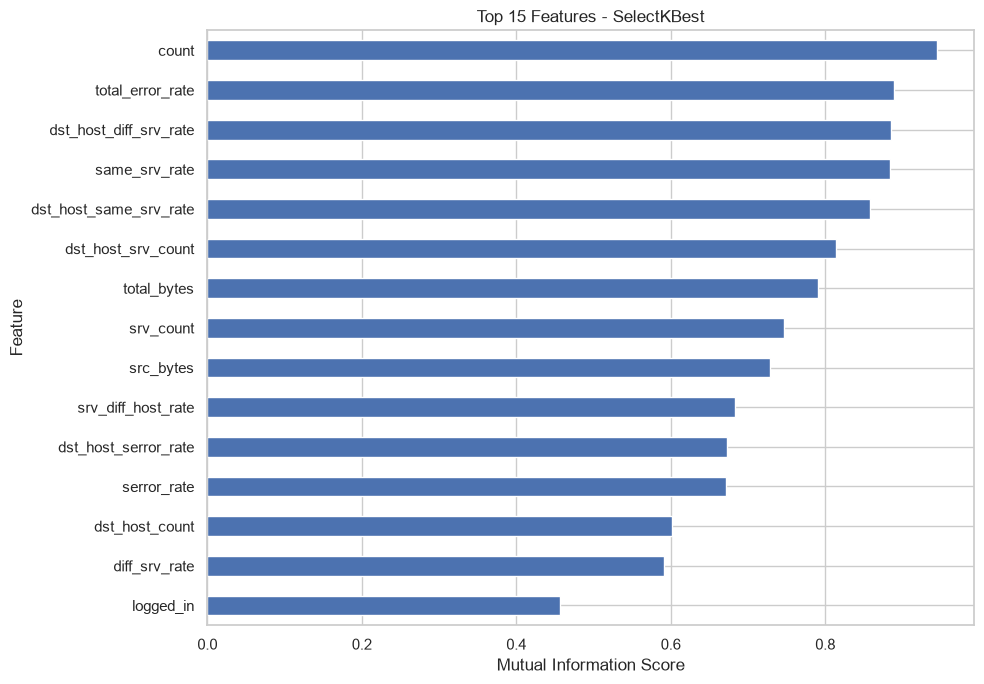

In [63]:
# Plot the top 15 SelectKBest features

top_kbest = kbest_scores.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_kbest.plot(kind="barh")

plt.title("Top 15 Features - SelectKBest")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Phase 4 Summary

- The dataset was split into training and testing sets using an 80:20 ratio.
- Stratified splitting was used to preserve the distribution of the five attack classes.
- Two meaningful network-related features were created:
  - total_bytes
  - total_error_rate
- Categorical features were encoded using OneHotEncoder.
- Random Forest Feature Importance was used to identify important features.
- SelectKBest with Mutual Information was used as a second feature-selection method.
- Feature selection was fitted using training data only to prevent data leakage.
- The selected features will be used in the machine learning models in the next phase.

# Phase 5 - Model Building and Training

In this phase, five machine learning classification models are trained:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Support Vector Machine (SVM)
5. K-Nearest Neighbors (KNN)

The models are trained using the selected features obtained from SelectKBest.

In [64]:
# Create the final selected feature datasets

X_train_final = X_train_processed[selected_feature_names]
X_test_final = X_test_processed[selected_feature_names]

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)
print("Number of selected features:", len(selected_feature_names))

Final training shape: (22400, 20)
Final testing shape: (5600, 20)
Number of selected features: 20


In [65]:
# Import the required classification models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [66]:
# Create the five required classification models

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN


In [67]:
# Train all five models using the training dataset

trained_models = {}

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train_final,
        y_train
    )

    trained_models[model_name] = model

print("\nAll five models trained successfully.")

Training Logistic Regression...


C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Decision Tree...
Training Random Forest...
Training SVM...


C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Training KNN...

All five models trained successfully.


In [68]:
# Generate predictions on the unseen test dataset

predictions = {}

for model_name, model in trained_models.items():

    predictions[model_name] = model.predict(
        X_test_final
    )

print("Predictions generated for all models.")

Predictions generated for all models.


In [69]:
from sklearn.metrics import accuracy_score

# Calculate test accuracy for each model

accuracy_results = {}

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    accuracy_results[model_name] = accuracy

# Display results

for model_name, accuracy in accuracy_results.items():

    print(
        f"{model_name}: {accuracy:.4f}"
    )

Logistic Regression: 0.9571
Decision Tree: 0.9836
Random Forest: 0.9895
SVM: 0.7486
KNN: 0.9395


In [70]:
# Create a DataFrame for model comparison

model_comparison = pd.DataFrame(
    {
        "Model": accuracy_results.keys(),
        "Accuracy": accuracy_results.values()
    }
)

# Sort models by accuracy

model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,Accuracy
0,Random Forest,0.989464
1,Decision Tree,0.983571
2,Logistic Regression,0.957143
3,KNN,0.939464
4,SVM,0.748571


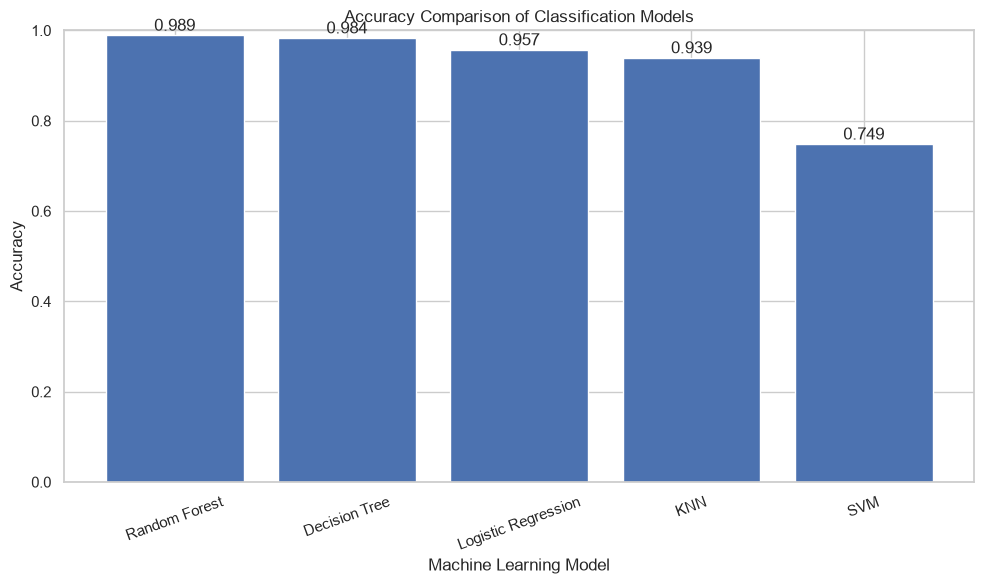

In [71]:
# Plot model accuracy comparison

plt.figure(figsize=(10, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Accuracy"]
)

plt.title("Accuracy Comparison of Classification Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.ylim(0, 1)

# Add accuracy values above bars

for i, value in enumerate(model_comparison["Accuracy"]):

    plt.text(
        i,
        value + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Phase 5 Summary

Five classification models were trained using the selected features:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- Support Vector Machine
- K-Nearest Neighbors

The models were trained using the training dataset and evaluated initially using the unseen test dataset.

A basic accuracy comparison was created.

Detailed evaluation using accuracy, precision, recall, F1-score, confusion matrix, ROC curves, cross-validation, and hyperparameter tuning will be performed in Phase 6.

# Phase 6 - Model Evaluation, Cross-Validation and Hyperparameter Tuning

The trained classification models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC Curve

Five-fold stratified cross-validation is performed to assess model robustness.

RandomizedSearchCV is then used to tune the hyperparameters of the models.

In [72]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
# Calculate evaluation metrics for all five models

evaluation_results = []

for model_name, y_pred in predictions.items():

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.957143,0.955837,0.957143,0.956008
1,Decision Tree,0.983571,0.983397,0.983571,0.983397
2,Random Forest,0.989464,0.989462,0.989464,0.989238
3,SVM,0.748571,0.631247,0.748571,0.669119
4,KNN,0.939464,0.933102,0.939464,0.934832


In [74]:
# Display detailed classification reports

for model_name, y_pred in predictions.items():

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

Logistic Regression
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1600
      Normal       0.97      0.98      0.98      2400
       Probe       0.95      0.95      0.95       800
         R2L       0.85      0.87      0.86       600
         U2R       0.78      0.59      0.67       200

    accuracy                           0.96      5600
   macro avg       0.91      0.88      0.89      5600
weighted avg       0.96      0.96      0.96      5600

Decision Tree
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      1600
      Normal       1.00      1.00      1.00      2400
       Probe       0.99      0.99      0.99       800
         R2L       0.92      0.94      0.93       600
         U2R       0.89      0.81      0.85       200

    accuracy                           0.98      5600
   macro avg       0.96      0.95      0.95      5600
weighted avg       0.98      0.98      0.98

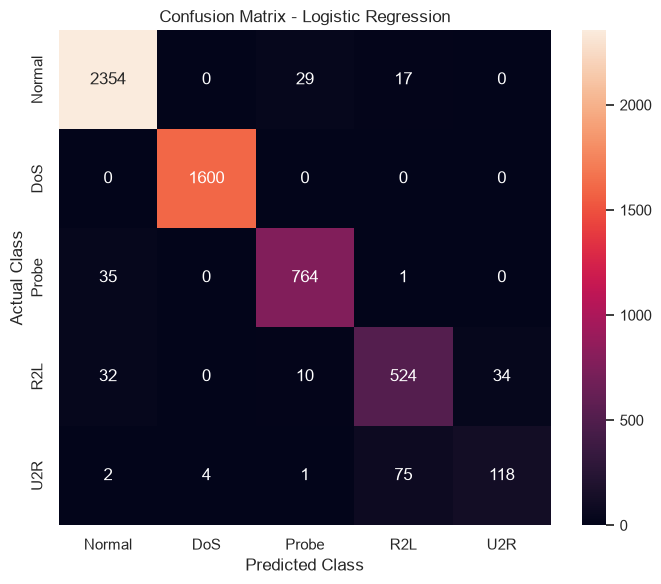

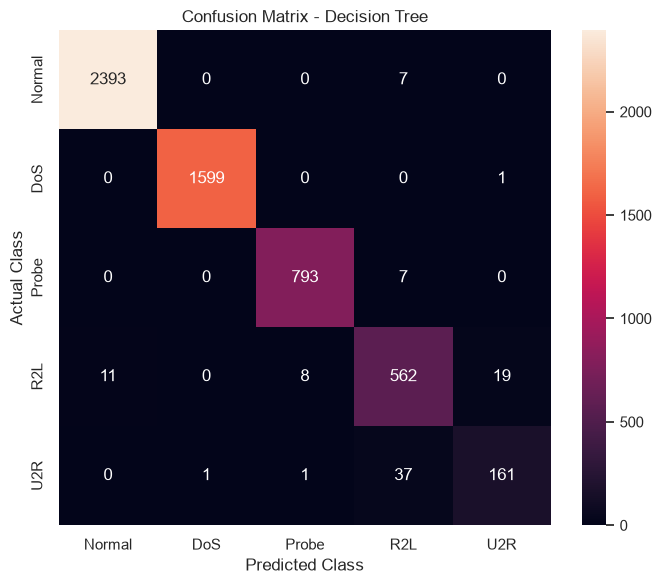

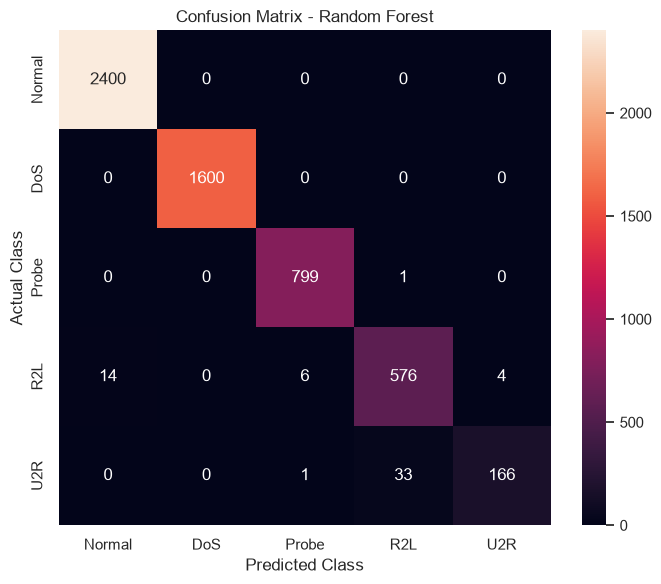

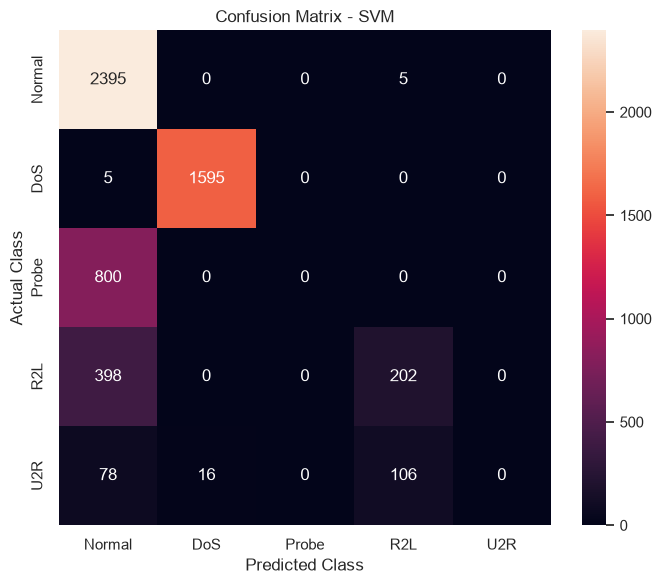

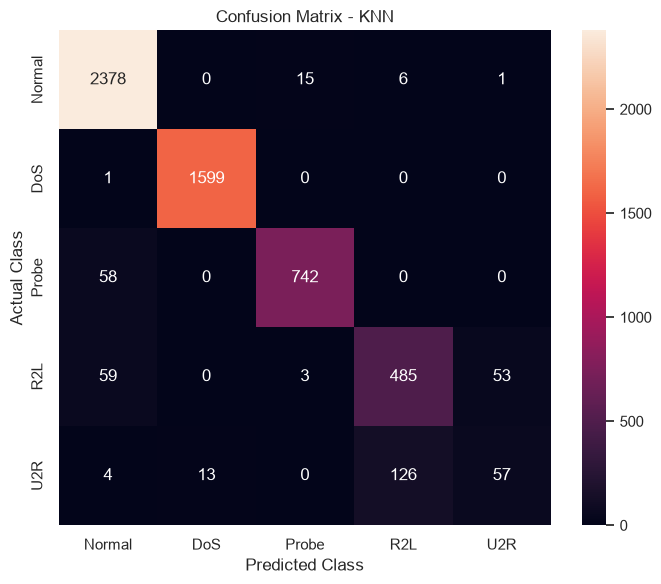

In [75]:
# Plot confusion matrices for all five models

class_labels = ["Normal", "DoS", "Probe", "R2L", "U2R"]

for model_name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=class_labels
    )

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

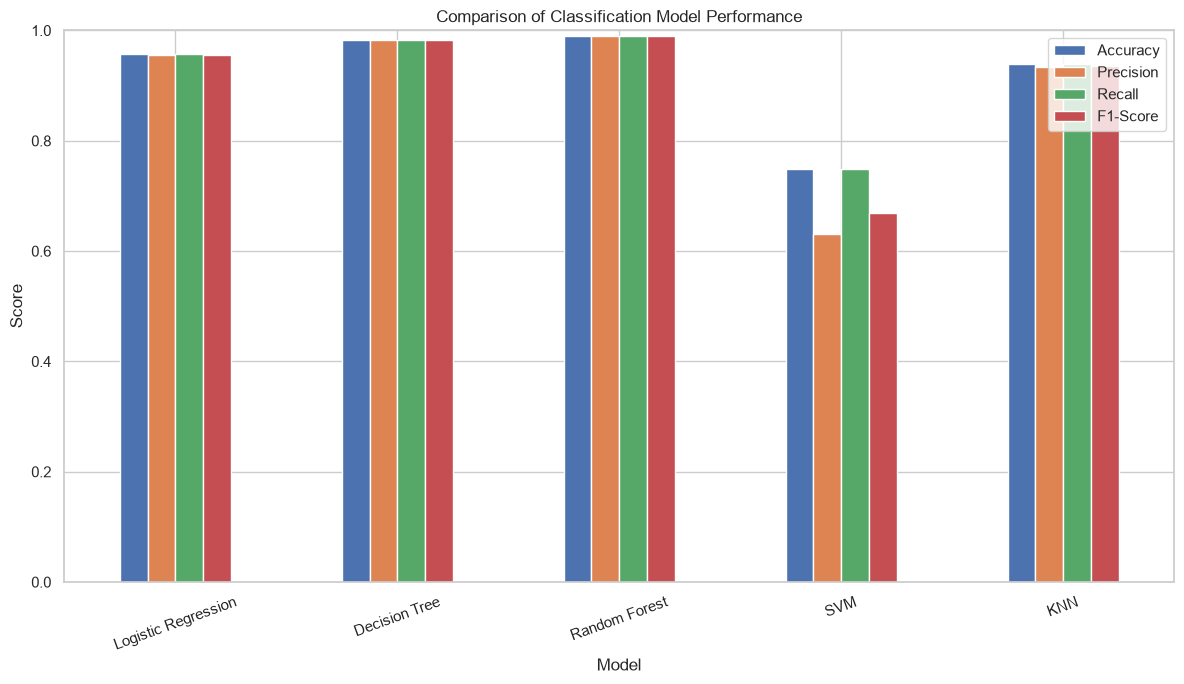

In [76]:
# Plot comparison of the four main evaluation metrics

metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

evaluation_df.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Comparison of Classification Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

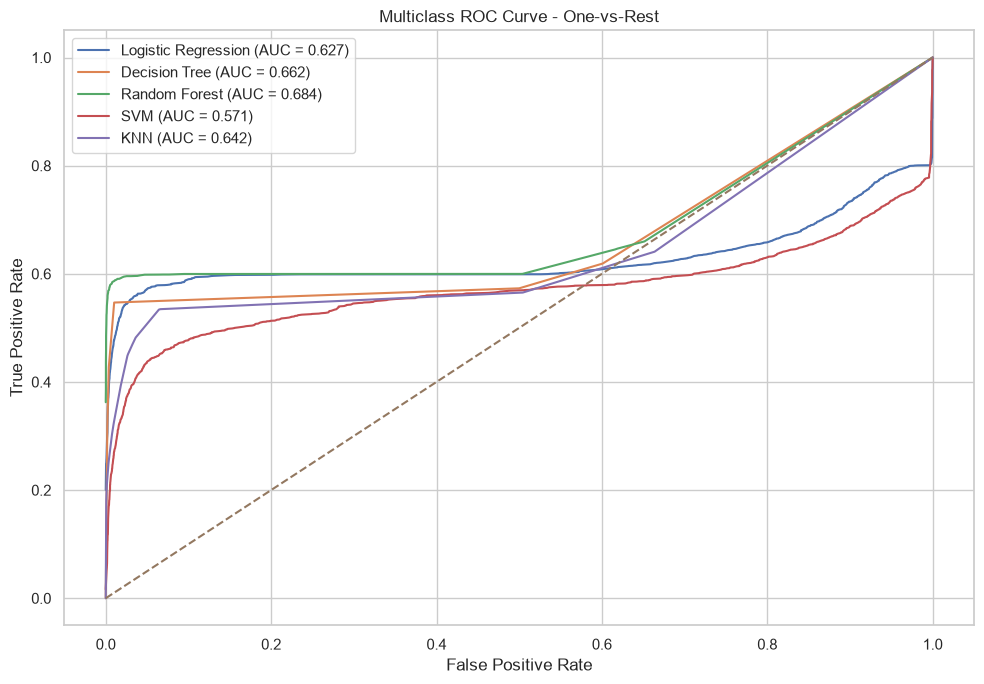

In [77]:
from sklearn.preprocessing import label_binarize

# Define class order

class_labels = ["Normal", "DoS", "Probe", "R2L", "U2R"]

# Convert actual target labels into binary format

y_test_binary = label_binarize(
    y_test,
    classes=class_labels
)

plt.figure(figsize=(10, 7))

for model_name, model in trained_models.items():

    # Get probability predictions

    y_score = model.predict_proba(X_test_final)

    # Calculate ROC values for each class

    fpr = {}
    tpr = {}

    for i in range(len(class_labels)):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            y_score[:, i]
        )

    # Calculate macro-average ROC

    all_fpr = np.unique(
        np.concatenate(
            [fpr[i] for i in range(len(class_labels))]
        )
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(class_labels)):

        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= len(class_labels)

    macro_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        label=f"{model_name} (AUC = {macro_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("Multiclass ROC Curve - One-vs-Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [78]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Create 5-fold stratified cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():

    print(f"Running 5-fold CV for {model_name}...")

    scores = cross_val_score(
        model,
        X_train_final,
        y_train,
        cv=cv,
        scoring="f1_weighted",
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV Mean F1": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df

Running 5-fold CV for Logistic Regression...
Running 5-fold CV for Decision Tree...
Running 5-fold CV for Random Forest...
Running 5-fold CV for SVM...
Running 5-fold CV for KNN...


,Model,CV Mean F1,CV Std
0,Logistic Regression,0.956336,0.003104
1,Decision Tree,0.983679,0.001326
2,Random Forest,0.991797,0.001503
3,SVM,0.667456,0.001879
4,KNN,0.938240,0.003284


In [79]:
from sklearn.model_selection import RandomizedSearchCV

In [80]:
# Hyperparameter tuning for Logistic Regression

lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "class_weight": [None, "balanced"]
}

lr_random = RandomizedSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_distributions=lr_params,
    n_iter=5,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)

lr_random.fit(
    X_train_final,
    y_train
)

print("Best Logistic Regression parameters:")
print(lr_random.best_params_)

print("\nBest CV F1-score:")
print(lr_random.best_score_)

C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:493: FitFailedWarning: 
15 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 855, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-pack

Best Logistic Regression parameters:
{'solver': 'lbfgs', 'class_weight': None, 'C': 0.01}

Best CV F1-score:
0.9567938000776065


C:\Users\abhin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [81]:
# Hyperparameter tuning for Decision Tree

dt_params = {
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(
        random_state=42
    ),
    param_distributions=dt_params,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)

dt_random.fit(
    X_train_final,
    y_train
)

print("Best Decision Tree parameters:")
print(dt_random.best_params_)

print("\nBest CV F1-score:")
print(dt_random.best_score_)

Best Decision Tree parameters:
{'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 15, 'criterion': 'gini'}

Best CV F1-score:
0.9860469380581964


In [82]:
# Hyperparameter tuning for Random Forest

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)

rf_random.fit(
    X_train_final,
    y_train
)

print("Best Random Forest parameters:")
print(rf_random.best_params_)

print("\nBest CV F1-score:")
print(rf_random.best_score_)

Best Random Forest parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

Best CV F1-score:
0.9918353647264595


In [83]:
# Hyperparameter tuning for KNN

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_random = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=knn_params,
    n_iter=10,
    cv=5,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1
)

knn_random.fit(
    X_train_final,
    y_train
)

print("Best KNN parameters:")
print(knn_random.best_params_)

print("\nBest CV F1-score:")
print(knn_random.best_score_)

Best KNN parameters:
{'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan'}

Best CV F1-score:
0.9405953527712887


# Phase 7: Final Model, Pipeline and Model Saving

In this phase, the best-performing tuned model is converted into a final
machine learning pipeline and saved for deployment through the Flask API.

In [84]:
# Import required libraries
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib
import os

In [85]:
# Create the final machine learning pipeline
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", rf_random.best_estimator_)
])

# Train the final pipeline
final_pipeline.fit(X_train_final, y_train)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [86]:
# Generate predictions using the final pipeline
final_predictions = final_pipeline.predict(X_test_final)

# Calculate final accuracy
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final Model Accuracy:", round(final_accuracy, 4))

Final Model Accuracy: 0.9898


In [87]:
# Create the models directory if it does not already exist
os.makedirs("../models", exist_ok=True)

# Save the final trained pipeline
joblib.dump(final_pipeline, "../models/final_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [88]:
# Save the selected feature names in the exact order used by the model
joblib.dump(
    selected_feature_names.tolist(),
    "../models/selected_features.pkl"
)

print("Selected features saved successfully.")
print("\nFeatures used by the final model:")
for i, feature in enumerate(selected_feature_names, start=1):
    print(f"{i}. {feature}")

Selected features saved successfully.

Features used by the final model:
1. duration
2. src_bytes
3. dst_bytes
4. logged_in
5. num_compromised
6. num_shells
7. count
8. srv_count
9. serror_rate
10. rerror_rate
11. same_srv_rate
12. diff_srv_rate
13. srv_diff_host_rate
14. dst_host_count
15. dst_host_srv_count
16. dst_host_same_srv_rate
17. dst_host_diff_srv_rate
18. dst_host_serror_rate
19. total_bytes
20. total_error_rate


In [89]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nModels folder contents:")
print(os.listdir("../models"))

Current working directory:
c:\Users\abhin\Network Intrusion Detection and Cyber Attack Classification System

Models folder contents:
['final_model.pkl', 'selected_features.pkl']
